<a href="https://colab.research.google.com/github/RafaMota26/Inform-tica/blob/main/Regress%C3%A3o_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raphaelmanayon/temperature-and-ice-cream-sales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'temperature-and-ice-cream-sales' dataset.
Path to dataset files: /kaggle/input/temperature-and-ice-cream-sales


In [16]:
import pandas as pd


In [17]:
import os
import pandas as pd

# Assuming the CSV file is named 'ice_cream_sales.csv' inside the downloaded path.
# If there are multiple CSVs, you might need to specify the correct one.
csv_file_path = os.path.join(path, 'Ice Cream Sales - temperatures.csv')

df = pd.read_csv(csv_file_path)
display(df.head())

,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02


## Regressão Linear

A Regressão Linear é um modelo estatístico simples usado para modelar a relação entre uma variável dependente (a que queremos prever) e uma ou mais variáveis independentes (as características que usamos para prever).

Neste caso, podemos tentar prever as vendas de sorvete (variável dependente) com base na temperatura (variável independente).

In [22]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns



X = df[['Temperature']].values
y = df['Ice Cream Profits'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")

Tamanho do conjunto de treino: 292 amostras
Tamanho do conjunto de teste: 73 amostras


### Treinamento do Modelo de Regressão Linear

In [23]:
# Criar e treinar o modelo de Regressão Linear
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coeficiente (inclinação): {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")

Coeficiente (inclinação): 1.19
Intercepto: -33.66


### Avaliação do Modelo

In [24]:
# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o desempenho do modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.2f}")

Erro Quadrático Médio (MSE): 5.29
Coeficiente de Determinação (R²): 0.98


### Visualização dos Resultados

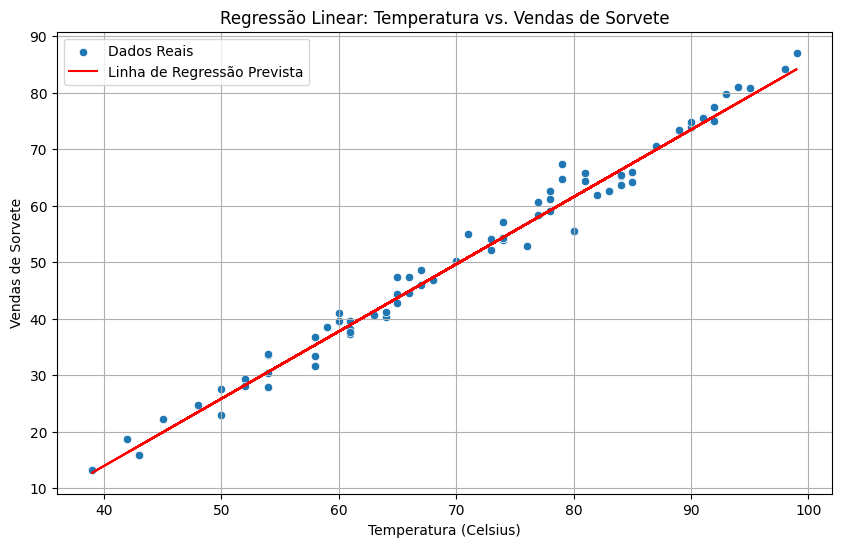

In [25]:
# Plotar os dados de teste e a linha de regressão
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test.flatten(), y=y_test, label='Dados Reais')
plt.plot(X_test.flatten(), y_pred, color='red', label='Linha de Regressão Prevista')
plt.title('Regressão Linear: Temperatura vs. Vendas de Sorvete')
plt.xlabel('Temperatura (Celsius)')
plt.ylabel('Vendas de Sorvete')
plt.legend()
plt.grid(True)
plt.show()